In [2]:
# Sample Data

import pandas as pd

# Create a dummy dataframe structure to simulate the actual CSV
columns = [
    "iteration",
    "layer_1_channels", "layer_1_filter", "layer_1_padding", "layer_1_param_count",
    "layer_2_channels", "layer_2_filter", "layer_2_padding", "layer_2_param_count",
    "layer_3_channel", "layer_3_filter", "layer_3_padding", "layer_3_param_count",
    "total_param_count"
]

# Generate a small sample to test the plotting functions
df = pd.DataFrame({
    "iteration": range(10),
    "layer_1_channels": [16, 32, 16, 16, 64, 64, 32, 64, 16, 16],
    "layer_1_filter": [3, 5, 3, 3, 5, 5, 7, 3, 3, 7],
    "layer_1_padding": [1, 2, 1, 1, 2, 0, 0, 1, 2, 1],
    "layer_1_param_count": [100]*10,
    "layer_2_channels": [64, 64, 64, 32, 64, 32, 64, 32, 64, 32],
    "layer_2_filter": [3, 3, 5, 3, 5, 5, 7, 3, 3, 7],
    "layer_2_padding": [1, 1, 2, 1, 2, 0, 0, 1, 2, 1],
    "layer_2_param_count": [200]*10,
    "layer_3_channel": [128, 64, 64, 128, 64, 128, 64, 128, 64, 128],
    "layer_3_filter": [3, 3, 5, 3, 5, 5, 7, 3, 3, 7],
    "layer_3_padding": [1, 1, 2, 1, 2, 0, 0, 1, 2, 1],
    "layer_3_param_count": [300]*10,
    "total_param_count": [600]*10
})

df.head()


,iteration,layer_1_channels,layer_1_filter,layer_1_padding,layer_1_param_count,layer_2_channels,layer_2_filter,layer_2_padding,layer_2_param_count,layer_3_channel,layer_3_filter,layer_3_padding,layer_3_param_count,total_param_count
0,0,16,3,1,100,64,3,1,200,128,3,1,300,600
1,1,32,5,2,100,64,3,1,200,64,3,1,300,600
2,2,16,3,1,100,64,5,2,200,64,5,2,300,600
3,3,16,3,1,100,32,3,1,200,128,3,1,300,600
4,4,64,5,2,100,64,5,2,200,64,5,2,300,600


In [15]:
import matplotlib.pyplot as plt

def plot_token_distribution(df, include_layer1=True, use_sns=False):
    """
    Plot token distributions (channels, filter, padding) in a 1x3 subplot layout.

    Args:
        df (pd.DataFrame): DataFrame containing architecture logs.
        include_layer1 (bool): Whether to include layer 1 in the plots.
        use_sns (bool): Whether to use seaborn or matplotlib styles.
    """
    token_map = {
        "channels": ["layer_1_channels", "layer_2_channels", "layer_3_channel"],
        "filter": ["layer_1_filter", "layer_2_filter", "layer_3_filter"],
        "padding": ["layer_1_padding", "layer_2_padding", "layer_3_padding"]
    }

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    fig.suptitle("Experiment Token Distribution", fontsize=16)

    for i, token_type in enumerate(["channels", "filter", "padding"]):
        layers = token_map[token_type]
        if not include_layer1:
            layers = layers[1:]

        df_tokens = df[layers].copy()
        df_tokens.columns = [f"Layer {j+1 if include_layer1 else j+2}" for j in range(len(layers))]
        df_melted = df_tokens.melt(var_name="Layer", value_name="Token")

        token_counts = df_melted.groupby(["Layer", "Token"]).size().reset_index(name="Count")
        pivot = token_counts.pivot(index="Layer", columns="Token", values="Count").fillna(0)

        ax = axs[i]
        pivot.plot(kind="bar", stacked=True, ax=ax, colormap="tab20c" if use_sns else None)
        ax.set_title(f"{token_type.capitalize()} Token Distribution")
        ax.set_ylabel("Count")
        ax.set_xlabel("Layer")
        ax.set_xticklabels(pivot.index, rotation=0)
        ax.legend(title=token_type.capitalize(), bbox_to_anchor=(1.05, 1), loc="upper left")
        ax.grid(axis='y')

    plt.tight_layout()
    plt.show()


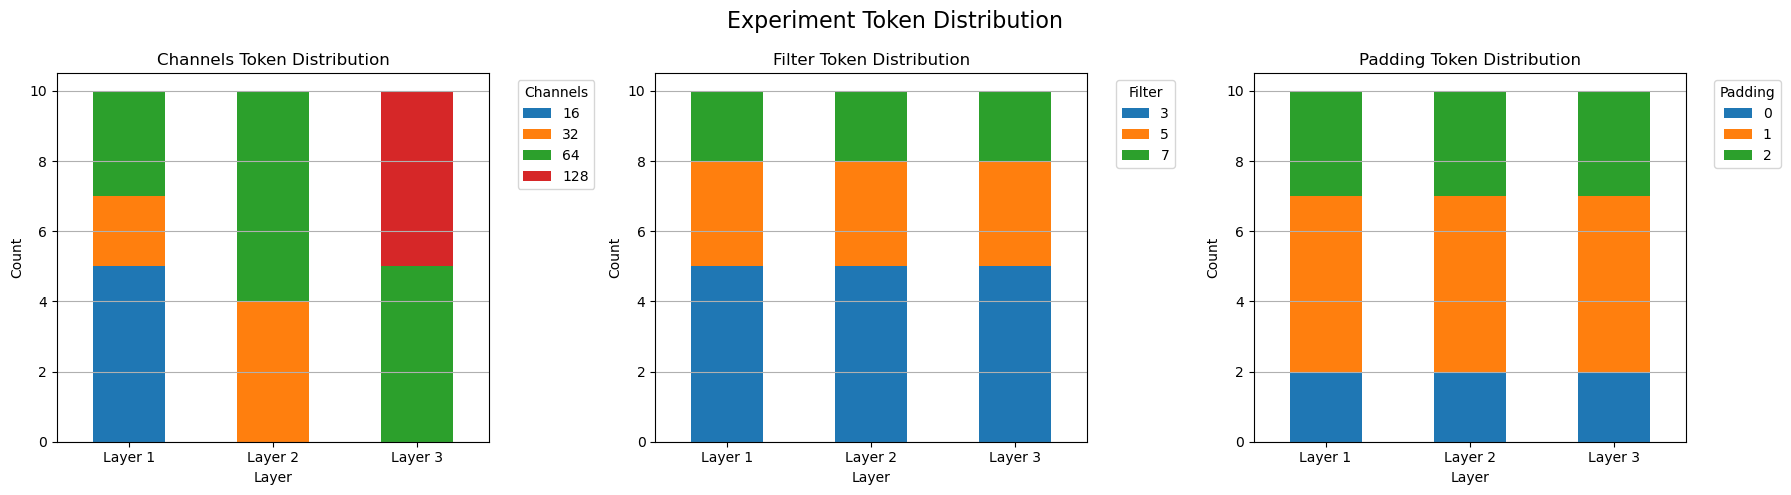

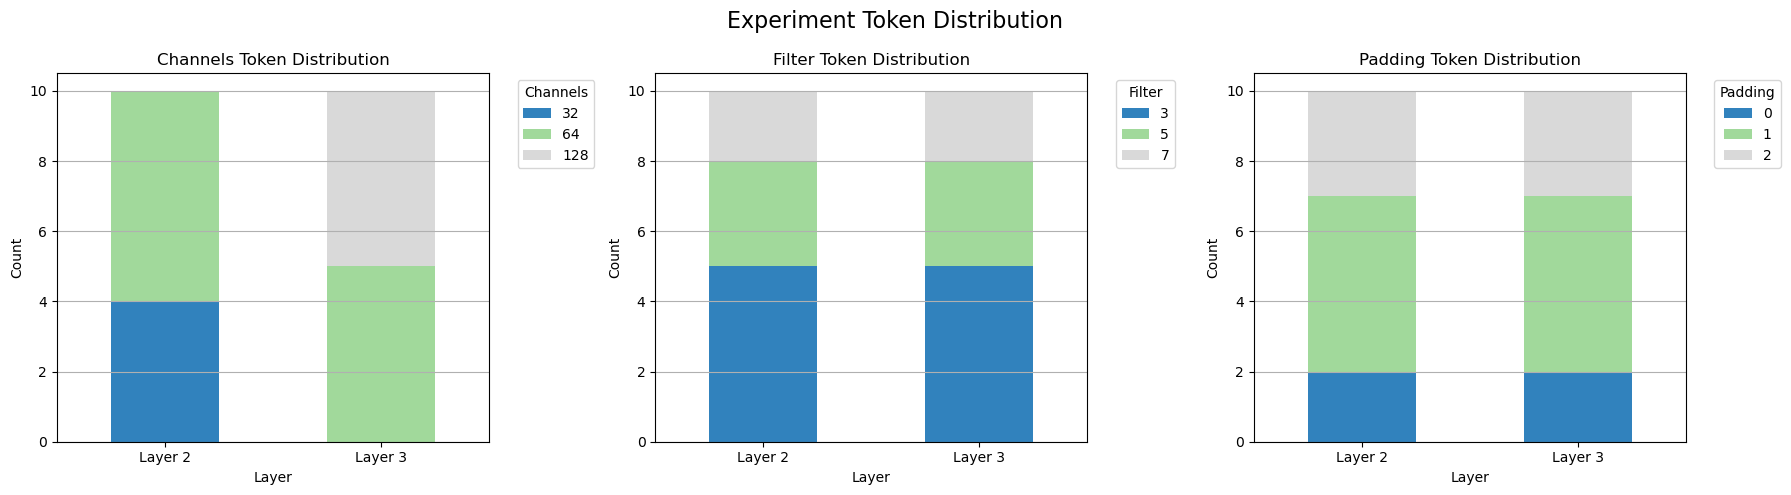

In [16]:
# Matplotlib version
plot_token_distribution(df, include_layer1=True, use_sns=False)

# Seaborn version
plot_token_distribution(df, include_layer1=False, use_sns=True)
